# Data Parallelism in PyTorch from Scratch

In this notebook, we train a neural network using single program multiple data (SPMD) parallelism. This is also known as "data parallelism".

To achieve data parallelism, we need to do a few things:

* Create a model from scratch. Instead of using `torch.Parameter`, we'll use `torch.Tensor` with `requires_grad = True`. We will perform the optimization step manually instead of using an optimizer from `torch.optim`. This also requires a function `get_init_params` to get initial parameters (on CPU).
* Broadcast parameters to multiple GPUs. This will require a function `broadcast_params` which will send the initial parameters (on CPU) to a list of devices (GPUs).
* Aggregate gradients on a single GPU, then send this gradient back to all of the other GPUs. This will be done using an `all_reduce` function to aggregate the values of list of tensors (each of the same shape), as well as a function `sync_gradients` to perform an all-reduce for every parameter value.
* Shard a batch. The batch elements will be of shape (N, ...) and we will use the pytorch function `torch.nn.parallel.scatter` to scatter the batch (on CPU) equally across the D devices (GPUs), so each batch is of size N//D.
* Compute the loss separately for each GPU, then compute the gradients of each parameter separately for the parameters on each GPU using `loss.backward()`. 


### Create model

In [2]:
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [3]:
assert torch.cuda.is_available()
print(torch.cuda.device_count())

2


In [4]:
def get_init_params() -> list[torch.Tensor]:
    W1 = nn.init.kaiming_normal_(torch.Tensor(20, 1, 3, 3))
    b1 = torch.zeros(20)
    W2 = nn.init.kaiming_normal_(torch.Tensor(50, 20, 5, 5))
    b2 = torch.zeros(50)
    W3 = nn.init.kaiming_normal_(torch.Tensor(2450, 128))
    b3 = torch.zeros(128)
    W4 = nn.init.kaiming_normal_(torch.Tensor(128, 10))
    b4 = torch.zeros(10)
    params = [W1, b1, W2, b2, W3, b3, W4, b4]
    return params

In [5]:
def lenet(X: torch.Tensor, params: list[torch.Tensor]) -> torch.Tensor:
    h1_conv = F.conv2d(input=X, weight=params[0], bias=params[1], padding=1)
    h1_activation = F.relu(h1_conv)
    h1 = F.avg_pool2d(h1_activation, kernel_size=2, stride=2)
    h2_conv = F.conv2d(input=h1, weight=params[2], bias=params[3], padding=2)
    h2_activation = F.relu(h2_conv)
    h2 = F.avg_pool2d(h2_activation, kernel_size=2, stride=2)
    h2 = h2.reshape(h2.shape[0], -1)
    h3_linear = torch.mm(h2, params[4]) + params[5]
    h3 = F.relu(h3_linear)
    return torch.mm(h3, params[6]) + params[7]

In [6]:
params = get_init_params()
X = torch.rand(64, 1, 28, 28)
print(lenet(X, params).shape)

torch.Size([64, 10])


### Broadcast parameters to multiple GPUs

In [7]:
def move_params(params, device):
    new_params = [p.to(device) for p in params]
    for p in new_params:
        p.requires_grad_(True)
    return new_params

def broadcast_params(
    params: list[torch.Tensor], 
    devices: list[torch.device]
) -> list[list[torch.Tensor]]:
    """Broadcasts a list of parameters across a list of devices"""
    return [move_params(params, d) for d in devices]

In [8]:
devices = [torch.device('cpu'), torch.device('cpu')]
params = get_init_params()
cpu_device_params = broadcast_params(params, devices)
print(len(cpu_device_params), len(cpu_device_params[0]), cpu_device_params[0][0].shape)

2 8 torch.Size([20, 1, 3, 3])


### Aggregate gradients onto single GPU

In [9]:
def all_reduce(data: list[torch.Tensor]) -> None:
    """Sum (reduce) the data from a list of tensors, then broadcast result to all tensors"""
    for i in range(1, len(data)):
        data[0] += data[i].to(data[0].device)
    for i in range(1, len(data)):
        data[i] = data[0].to(data[i].device)

In [20]:
def sync_gradients(device_params: list[list[torch.Tensor]]) -> None:
    with torch.no_grad():
        for i in range(len(device_params[0])):
            all_reduce([device_params[d][i].grad for d in range(len(device_params))])

### Shard batch across devices

In [21]:
def shard_tensor(
    x: torch.Tensor, 
    devices: list[torch.device]
) -> tuple[torch.Tensor]:
    return nn.parallel.scatter(x, devices)

In [22]:
def shard_batch(X, y, devices):
    assert X.shape[0] == y.shape[0]
    return (shard_tensor(X, devices), 
            shard_tensor(y, devices))

### Train model

In [23]:
def sgd(params: torch.Tensor, lr: float, batch_size: int):
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad / batch_size
            p.grad.zero_()

def loss_fn(X, y, params):
    y_hat = lenet(X, params)
    return F.cross_entropy(y_hat, y, reduction='sum')

In [25]:
def train_step(
    X: torch.Tensor, 
    y: torch.Tensor, 
    device_params: list[list[torch.Tensor]], 
    devices: list[torch.device], 
    lr: float
) -> None:
    X_shard, y_shard = shard_batch(X, y, devices)
    ls = [loss_fn(Xs, ys, params) for Xs, ys, params in zip(X_shard, y_shard, device_params)]
    for l in ls:
        l.backward()
    sync_gradients(device_params)
    for params in device_params:
        sgd(params, lr, X.shape[0])
    return sum([l.to('cpu') for l in ls]) / X.shape[0]

In [26]:
def load_fashion_mnist(batch_size=128):
    train_ds = datasets.FashionMNIST(root='data', transform=transforms.ToTensor(), train=True, download=True)
    val_ds = datasets.FashionMNIST(root='data', transform=transforms.ToTensor(), train=False, download=True)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_dl, val_dl

In [27]:
def train(num_gpus=1, batch_size=128, lr=0.1):
    assert torch.cuda.is_available(), "CUDA not available"
    train_dl, val_dl = load_fashion_mnist(batch_size=batch_size*num_gpus)
    devices = [torch.device(f"cuda:{i}") for i in range(num_gpus)]
    device_params = broadcast_params(get_init_params(), devices)
    num_epochs = 10
    losses = []
    for _ in range(num_epochs):
        for X, y in train_dl:
            loss = train_step(X, y, device_params, devices, lr)
            losses.append(loss.item())
    return losses

In [28]:
num_gpus, batch_size, lr = 2, 128, 0.1
losses = train(num_gpus, batch_size, lr)

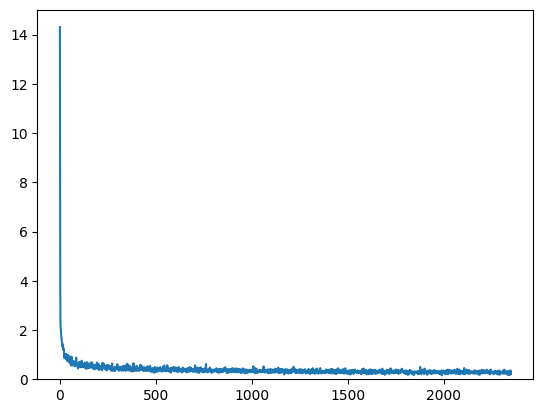

In [29]:
plt.plot(losses)
plt.ylim(bottom=0.0)
plt.show()